# 05 · Service Complexity Baseline (RQ1)

A transparent baseline score from structural features, grouped by administrative-burden cost type (compliance vs. learning). Equal weights and fixed reference caps; no weighting is claimed to be correct.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'ml-service'))
import pandas as pd
import matplotlib.pyplot as plt
from chlatvei_ml.data import Dataset
pd.set_option('display.width', 160)
RESULTS = Path('..') / 'data' / 'evaluation' / 'results'
# Chart style: categorical palette validated for colour-blind separation (see docs/data-science/phase6_report.md)
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
SURFACE, INK, MUTED = '#fcfcfb', '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': MUTED, 'axes.labelcolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True, 'font.size': 10})
ds = Dataset.load()

## Features
Computed from the annotated facts. `information_gaps` counts core fields the official source does not state.

In [2]:
from chlatvei_ml import complexity as cx
features = cx.service_features(ds.facts)
pd.DataFrame([{ 'feature': f.name, 'cost type': f.cost, 'reference cap': f.cap } for f in cx.FEATURES])

,feature,cost type,reference cap
0,documents,compliance,10
1,steps,compliance,10
2,fee_tiers,compliance,6
3,max_fee_khr,compliance,1000000
4,conditions,learning,6
5,information_gaps,learning,7


In [3]:
features

,documents,steps,fee_tiers,max_fee_khr,conditions,information_gaps
service_slug,,,,,,
driver_license_ab,3,3,4,180000.0,3,1
driver_license_exchange,6,0,1,120000.0,2,2
vehicle_registration,4,3,2,125000.0,0,1


## Scores and what drives them
Each `part_*` column is that feature's share of the 0–100 score.

In [4]:
scores = cx.score(features)
scores['main contributors'] = [', '.join(cx.explain(r)) for _, r in scores.iterrows()]
scores

,score,part_documents,part_steps,part_fee_tiers,part_max_fee_khr,part_conditions,part_information_gaps,main contributors
service_slug,,,,,,,,
driver_license_ab,34.8,5.0,5.0,11.1,3.0,8.3,2.4,"Many different fees, Many conditions to unders..."
driver_license_exchange,25.1,10.0,0.0,2.8,2.0,5.6,4.8,"Many required documents, Many conditions to un..."
vehicle_registration,21.7,6.7,5.0,5.6,2.1,0.0,2.4,"Many required documents, Many different fees, ..."


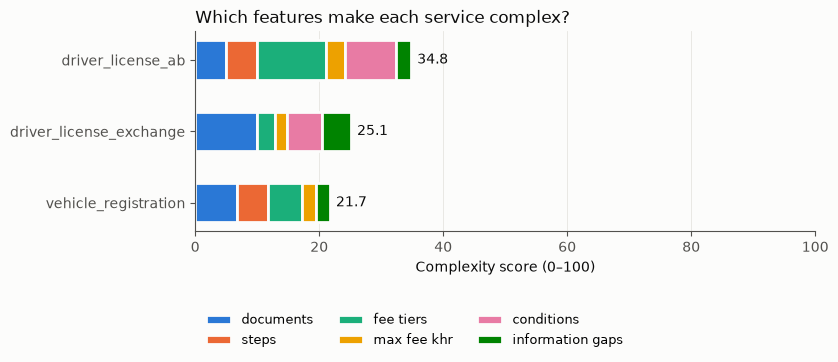

In [5]:
parts = scores[[c for c in scores.columns if c.startswith('part_')]]
labels = [c.removeprefix('part_').replace('_', ' ') for c in parts.columns]
fig, ax = plt.subplots(figsize=(8, 2.6))
left = pd.Series(0.0, index=parts.index)
for i, col in enumerate(parts.columns):
    ax.barh(parts.index, parts[col], left=left, color=PALETTE[i], edgecolor=SURFACE, linewidth=2, height=0.55, label=labels[i])
    left += parts[col]
for y, total in enumerate(scores['score']):
    ax.text(total + 1, y, f'{total:.1f}', va='center', color=INK)
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel('Complexity score (0–100)'); ax.grid(axis='y', visible=False)
ax.legend(ncol=3, frameon=False, bbox_to_anchor=(0, -0.35), loc='upper left', fontsize=9)
ax.set_title('Which features make each service complex?', loc='left', color=INK)
plt.show()

## Sensitivity: does the ranking depend on the equal weights?
2,000 random weightings (flat Dirichlet). If the ranking changes often, the services cannot be ranked confidently from structure alone.

In [6]:
sens = cx.sensitivity(features)
print(f"Equal-weight order reproduced in {sens.attrs['same_order_share']:.0%} of weightings")
sens

Equal-weight order reproduced in 52% of weightings


,baseline_rank,mean_rank,best,worst
driver_license_ab,1.0,1.1850,1.0,3.0
driver_license_exchange,2.0,2.1565,1.0,3.0
vehicle_registration,3.0,2.6585,1.0,3.0


## Validation against citizen feedback
The score is only meaningful if it agrees with what citizens report. That needs feedback on at least 8 services; none exists yet, so the check refuses to report a number.

In [7]:
cx.validate_against_feedback(scores['score'], pd.Series(dtype=float))

{'status': 'insufficient data: 0 services with feedback (need 8)'}

## Limitations
- Only 3 services are annotated: scores are illustrative, not findings about Cambodian services in general.
- Reference caps (e.g. 10 documents, 1,000,000 riel) are assumptions; they are listed above and easy to change.
- A missing field counts as an information gap, not as zero effort; e.g. the exchange service shows 0 steps because steps are not stated.